In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [5, 4]

In [5]:
x = pd.read_csv('../../../Downloads/x.csv')
y = pd.read_csv('../../../Downloads/y.csv')

In [6]:
x.head()
# print(y.head())

,Unnamed: 0,0
0,0,1.462108
1,1,1.133769
2,2,-2.301539
3,3,1.744812
4,4,0.042214


In [7]:
x = pd.read_csv('../../../Downloads/x.csv', index_col=0)['0']
y = pd.read_csv('../../../Downloads/y.csv', index_col=0)['0']

In [8]:
x.info()

<class 'pandas.core.series.Series'>
Index: 20 entries, 0 to 19
Series name: 0
Non-Null Count  Dtype  
--------------  -----  
20 non-null     float64
dtypes: float64(1)
memory usage: 320.0 bytes


In [9]:
x.head()

0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

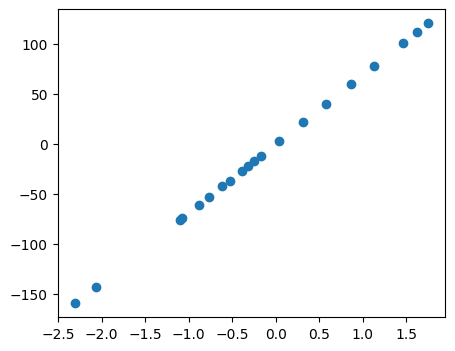

In [10]:
plt.figure()
plt.scatter(x, y)
plt.show()

In [11]:
class Model(object):
    def __init__(self):
        self.b0 = 0
        self.b1 = 0

    def predict(self, x):
        return self.b0 + self.b1 * x

    def MSE(self, X, Y):    
        return sum((self.predict(X) - Y)**2) / (2 * len(X))

    def fit(self, X, Y):  
        lr = 0.1
        dJ0 = sum(self.predict(X) - Y) /len(X)
        dJ1 = sum((self.predict(X) - Y) * X) /len(X)
        self.b0 -= lr * dJ0
        self.b1 -= lr * dJ1

In [12]:
hyp = Model()
print(hyp.predict(0))
print(hyp.predict(100))
J = hyp.MSE(x, y)
print("initial error:", J)

0
0
initial error: 2937.6446095153397


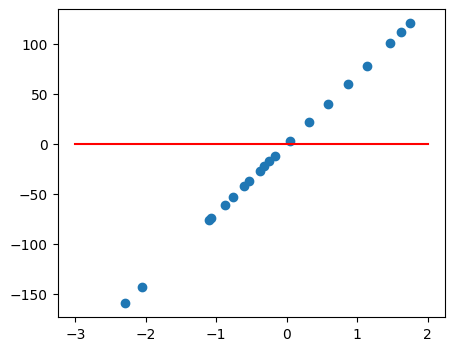

In [13]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [14]:
hyp.fit(x, y)
J = hyp.MSE(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2253.745680891855


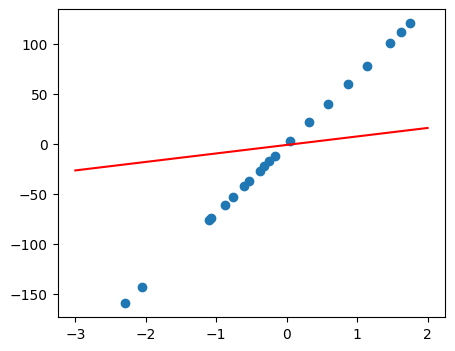

In [15]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

In [45]:
class Model(object):
    # Модель парной линейной регрессии
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
    def predict(self, X):
        return self.b0 + self.b1 * X
    def MSE(self, X, Y):
        return sum(((self.predict(X) - Y)**2) / (2 * len(X)))
    def fit(self, X, Y, lr=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = hyp.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

In [17]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.MSE(x, y)
print("error after gradient descent:", J)

error after gradient descent: 2.776975306056007e-06


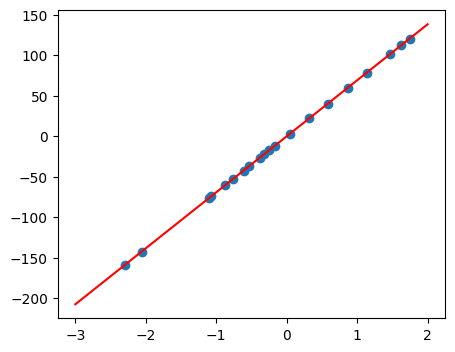

In [18]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)
plt.figure()
plt.scatter(x, y)
plt.plot(X0, Y0, 'r')
plt.show()

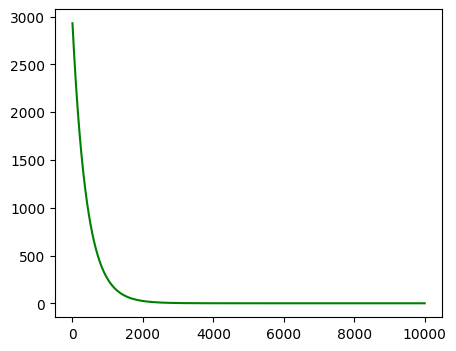

In [19]:
plt.figure()
plt.plot(steps, errors, 'g')
plt.show()

# Выполнение задания

In [49]:
class Model(object):
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y)**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y) /len(X)
            dJ1 = sum((self.predict(X) - Y) * X) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

## 1) начальные значения

In [21]:
initial_params = [
    (0, 0),
    (10, 10),
    (-10, -10),
    (100, -50),
    (1000, 1000),
    (48, 48)
]

for b0_init, b1_init in initial_params:
    model = Model(b0=b0_init, b1=b1_init)
    steps, errors = model.fit(x, y, lr=0.01)
    print(f"{b0_init:3d}, {b1_init:3d} -> b0={model.b0:.4f}, b1={model.b1:.4f}, ошибка={model.MSE(x,y):.6f}")

  0,   0 -> b0=-0.0000, b1=69.1877, ошибка=0.000000
 10,  10 -> b0=-0.0000, b1=69.1877, ошибка=0.000000
-10, -10 -> b0=-0.0000, b1=69.1877, ошибка=0.000000
100, -50 -> b0=0.0000, b1=69.1877, ошибка=0.000000
1000, 1000 -> b0=0.0000, b1=69.1877, ошибка=0.000000
 48,  48 -> b0=0.0000, b1=69.1877, ошибка=0.000000


Модель всегда сходится к оптимуму независимо от начальных значений

## 2) скорость обучения

In [22]:
learning_rate = [0.0001, 0.001, 0.01, 0.1, 1, 2, 3, 4]
results = {}

for lr in learning_rate:
    model = Model(b0=0, b1=0)

    steps, errors_history = model.fit(x, y, lr=lr)

    results[lr] = errors_history

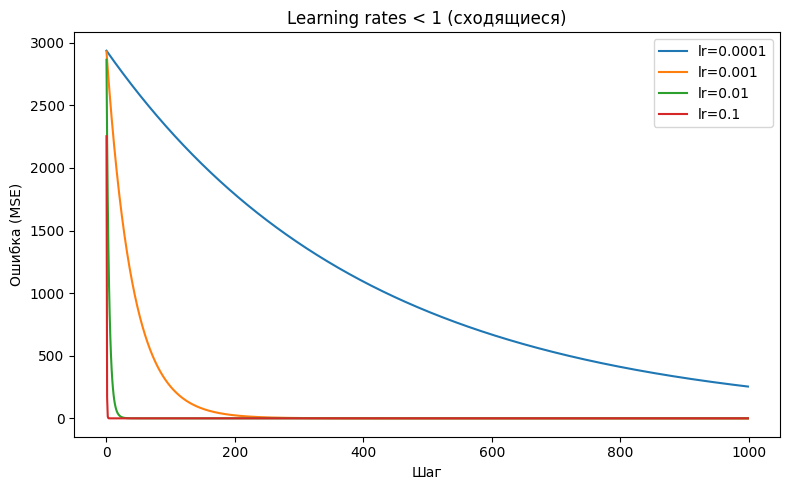

In [23]:
plt.figure(figsize=(8, 5))
for lr in [0.0001, 0.001, 0.01, 0.1]:
    plt.plot(results[lr][::10], label=f'lr={lr}')
plt.xlabel('Шаг')
plt.ylabel('Ошибка (MSE)')
plt.title('Learning rates < 1 (сходящиеся)')
plt.legend()
plt.tight_layout()
plt.show()

- lr = 0.0001 - очень медленная сходимость, ошибка уменьшается крайне медленно
- lr = 0.001 - стабильная, но относительно медленная сходимость
- lr = 0.01 - быстрая и стабильная сходимость
- lr = 0.1 - очень быстрая сходимость, ошибка быстро достигает минимума

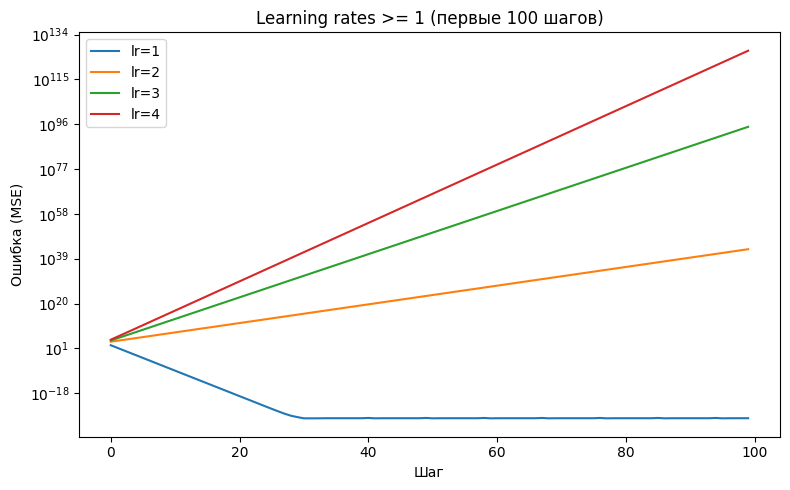

In [24]:
plt.figure(figsize=(8, 5))
for lr in [1, 2, 3, 4]:
    plt.plot(results[lr][:100], label=f'lr={lr}')
plt.xlabel('Шаг')
plt.ylabel('Ошибка (MSE)')
plt.title('Learning rates >= 1 (первые 100 шагов)')
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()

- lr = 1 - граничное значение: алгоритм ещё сходится, но находится на границе устойчивости
- lr = 2 - начинается расходимость, ошибка начинает расти
- lr = 3 - быстрая расходимость, ошибка увеличивается экспоненциально
- lr = 4 - сильная расходимость, ошибка растёт очень быстро

## 3) работа с Series и DataFrame

In [25]:
x_DF = x.to_frame()
y_DF = y.to_frame()

In [48]:
class Model(object):
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0]
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0        
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y.iloc[:, 0]) /len(X)
            dJ1 = sum((self.predict(X) - Y.iloc[:, 0]) * X.iloc[:, 0]) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
        return steps, errors

In [27]:
model = Model(b0=0, b1=0)
steps, errors_history = model.fit(x_DF, y_DF, lr=0.001)

In [28]:
for i in range(0, len(errors_history), 200):
    print(f"Шаг {steps[i]}: ошибка = {errors_history[i]:.6f}")

Шаг 1: ошибка = 2930.352957
Шаг 201: ошибка = 1784.732137
Шаг 401: ошибка = 1089.749306
Шаг 601: ошибка = 667.252716
Шаг 801: ошибка = 409.805308
Шаг 1001: ошибка = 252.524421
Шаг 1201: ошибка = 156.164583
Шаг 1401: ошибка = 96.945365
Шаг 1601: ошибка = 60.428711
Шаг 1801: ошибка = 37.829388
Шаг 2001: ошибка = 23.788742
Шаг 2201: ошибка = 15.029411
Шаг 2401: ошибка = 9.541046
Шаг 2601: ошибка = 6.086534
Шаг 2801: ошибка = 3.901937
Шаг 3001: ошибка = 2.513748
Шаг 3201: ошибка = 1.627305
Шаг 3401: ошибка = 1.058466
Шаг 3601: ошибка = 0.691644
Шаг 3801: ошибка = 0.453948
Шаг 4001: ошибка = 0.299197
Шаг 4201: ошибка = 0.197984
Шаг 4401: ошибка = 0.131498
Шаг 4601: ошибка = 0.087642
Шаг 4801: ошибка = 0.058599
Шаг 5001: ошибка = 0.039295
Шаг 5201: ошибка = 0.026421
Шаг 5401: ошибка = 0.017808
Шаг 5601: ошибка = 0.012029
Шаг 5801: ошибка = 0.008141
Шаг 6001: ошибка = 0.005520
Шаг 6201: ошибка = 0.003748
Шаг 6401: ошибка = 0.002549
Шаг 6601: ошибка = 0.001735
Шаг 6801: ошибка = 0.001183
Шаг 7

## 4) остановка градиентного спуска 

In [29]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0]
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000, eps = 0.0001):
        steps, errors = [], []
        step = 0   
        prev_err = 10000
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y.iloc[:, 0]) /len(X)
            dJ1 = sum((self.predict(X) - Y.iloc[:, 0]) * X.iloc[:, 0]) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
            if (abs(prev_err - new_err) < eps):
                print(f"Остановка на шаге {step}, ошибка = {new_err:.6f}, предыдущая ошибка = {prev_err:.6f}")
                break
            prev_err = new_err
        return steps, errors

In [30]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr=0.001)

Остановка на шаге 4881, ошибка = 0.049925, предыдущая ошибка = 0.050025


## 5) остановка градиентного спуска max_step и разница ошибки

In [50]:
class Model(object):
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0]
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000, eps = 0.0001):
        steps, errors = [], []
        step = 0   
        prev_err = 10000
        for _ in range(max_steps):
            dJ0 = sum(self.predict(X) - Y.iloc[:, 0]) /len(X)
            dJ1 = sum((self.predict(X) - Y.iloc[:, 0]) * X.iloc[:, 0]) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
            if (abs(prev_err - new_err) < eps):
                print(f"Остановка на шаге {step}, ошибка = {new_err:.6f}, предыдущая ошибка = {prev_err:.6f}")
                break
            if (max_steps == step):
                print(f"Остановка на шаге {step}, превышено max_steps")
                break
            prev_err = new_err
        return steps, errors

In [32]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr=0.001)

Остановка на шаге 4881, ошибка = 0.049925, предыдущая ошибка = 0.050025


In [33]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr=0.000001)

Остановка на шаге 5000, превышено max_steps


## 6) Адаптивная скорость обучения

Реализуйте механизм адаптивной скорости обучения. Чтобы не задавать вручную параметр alpha можно отслеживать, увеличивается ли ошибка после первого шага градиентного спуска. В начале задаем скорость обучения близкой к 1. Если ошибка после одного шага увеличивается - скорость обучения надо уменьшить (например, в 2 раза). Если не увеличивается - скорость обучения можно не трогать. Еще подумайте, как после уменьшения скорости перезапускать градиентный спуск заново.

In [51]:
class Model(object):
    def __init__(self, b0=0, b1=0):
        self.b0 = b0
        self.b1 = b1 
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0] 
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr=1, accuracy=0.01, max_steps=5000, eps=0.0001):
        steps, errors = [], []
        step = 0
        prev_err = self.MSE(X, Y)
        
        b0_start, b1_start = self.b0, self.b1
        
        for _ in range(max_steps):
            residuals = self.predict(X) - Y.iloc[:, 0]
            dJ0 = sum(residuals) / len(X)
            dJ1 = sum(residuals * X.iloc[:, 0]) / len(X)
            new_b0 = self.b0 - lr * dJ0
            new_b1 = self.b1 - lr * dJ1
            
            old_b0, old_b1 = self.b0, self.b1
            self.b0, self.b1 = new_b0, new_b1
            
            new_err = self.MSE(X, Y)
            step += 1
            steps.append(step)
            errors.append(new_err)
            
            if new_err > prev_err:
                lr = lr / 2
                self.b0, self.b1 = old_b0, old_b1
                print(f'Шаг {step}: ошибка увеличилась ({prev_err:.6f} -> {new_err:.6f}), '
                      f'уменьшаем lr до {lr:.6f}, откатываем параметры')
                
                if lr < eps:
                    print(f"Скорость обучения стала слишком маленькой ({lr:.6f}), останавливаемся")
                    break
                    
                steps.pop()
                errors.pop()
                step -= 1
                continue
            
            if abs(prev_err - new_err) < eps:
                print(f"Остановка на шаге {step}, ошибка = {new_err:.6f}, "
                      f"изменение = {abs(prev_err - new_err):.6f}")
                break
                
            if step >= max_steps:
                print(f"Остановка на шаге {step}, превышено max_steps")
                break
            
            prev_err = new_err
        return steps, errors

In [35]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr = 1)

Остановка на шаге 8, ошибка = 0.000006, изменение = 0.000066


## 7) метод рисования графиков

In [52]:
class Model(object):
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0]
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000, eps = 1e-6):
        steps, errors = [], []
        step = 0   
        prev_err = 10000
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y.iloc[:, 0]) /len(X)
            dJ1 = sum((self.predict(X) - Y.iloc[:, 0]) * X.iloc[:, 0]) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
            if (abs(prev_err - new_err) < eps):
                print(f"Остановка на шаге {step}, ошибка = {new_err:.6f}, предыдущая ошибка = {prev_err:.6f}")
                break
            prev_err = new_err
        return steps, errors
    def graphs(self, steps, errors):
        steps = np.array(steps)
        errors = np.array(errors)

        steps_norm = (steps - steps.min()) / (steps.max() - steps.min())
        errors_norm = (errors - errors.min()) / (errors.max() - errors.min())
        
        plt.figure()
        plt.plot(steps, errors)
        plt.xlabel('Шаг обучения')
        plt.ylabel('Ошибка (MSE)')
        plt.title('Кривая обучения')
        plt.show()

In [37]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr=0.001)

Остановка на шаге 7227, ошибка = 0.000524, предыдущая ошибка = 0.000525


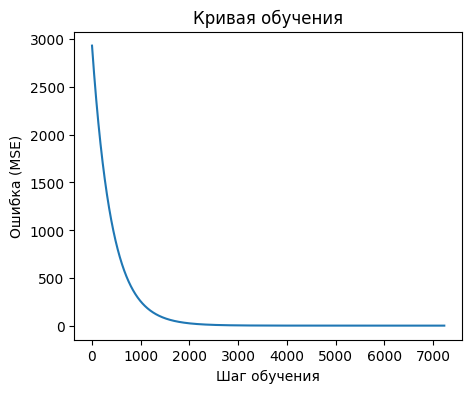

In [38]:
model.graphs(steps, errors)

In [39]:
model = Model()
x_big = x_DF * 100
y_big = y_DF * 100
steps, errors = model.fit(x_big, y_big, lr=0.00001)

Остановка на шаге 115, ошибка = 0.002782, предыдущая ошибка = 0.002782


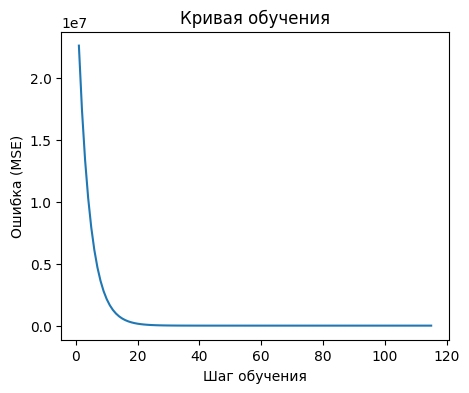

In [40]:
model.graphs(steps, errors)

### без нормализации:

In [41]:
class Model(object):
    """Модель парной линейной регрессии"""
    def __init__(self, b0 = 0, b1 = 0):
        self.b0 = b0
        self.b1 = b1
    def predict(self, X):
        return self.b0 + self.b1 * X.iloc[:, 0]
    def MSE(self, X, Y):
        return sum((self.predict(X) - Y.iloc[:, 0])**2) / (2 * len(X))
    def fit(self, X, Y, lr, accuracy=0.01, max_steps=5000, eps = 1e-6):
        steps, errors = [], []
        step = 0   
        prev_err = 10000
        for _ in range(10000):
            dJ0 = sum(self.predict(X) - Y.iloc[:, 0]) /len(X)
            dJ1 = sum((self.predict(X) - Y.iloc[:, 0]) * X.iloc[:, 0]) /len(X)
            self.b0 -= lr * dJ0
            self.b1 -= lr * dJ1    
            new_err = self.MSE(X, Y)
            step += 1            
            steps.append(step)
            errors.append(new_err)
            if (abs(prev_err - new_err) < eps):
                print(f"Остановка на шаге {step}, ошибка = {new_err:.6f}, предыдущая ошибка = {prev_err:.6f}")
                break
            prev_err = new_err
        return steps, errors
    def graphs(self, steps, errors):
        plt.figure()
        plt.plot(steps, errors)
        plt.xlabel('Шаг обучения')
        plt.ylabel('Ошибка (MSE)')
        plt.title('Кривая обучения')
        plt.show()

Остановка на шаге 7227, ошибка = 0.000524, предыдущая ошибка = 0.000525


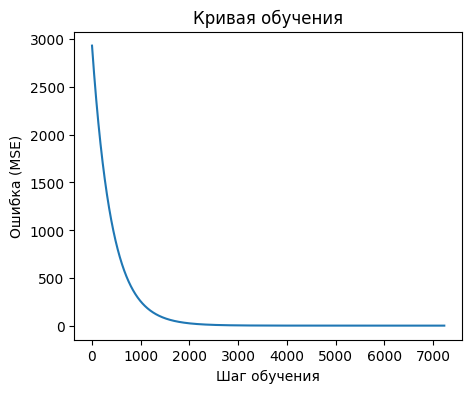

In [42]:
model = Model()
steps, errors = model.fit(x_DF, y_DF, lr=0.001)
model.graphs(steps, errors)

Остановка на шаге 14, ошибка = 0.000028, предыдущая ошибка = 0.000028


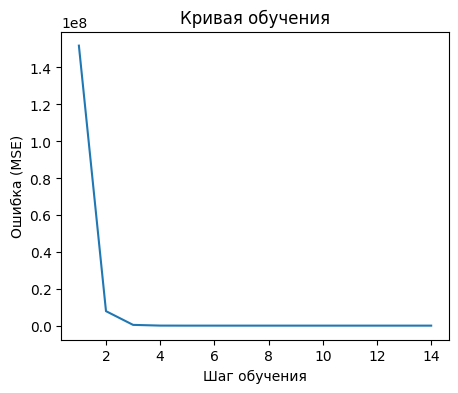

In [43]:
model = Model()
x_big = x_DF * 1000
y_big = y_DF * 1000
steps, errors = model.fit(x_big, y_big, lr=0.000001)
model.graphs(steps, errors)